## Prework & Feature engineering

In [1]:
import pandas as pd

train_df = pd.read_csv("Parte 2/entrenamiento.csv")

### 1. Feature engineering

In [2]:
## Relación superficie cubierta / total

train_df["covered_ratio"] = train_df["surface_covered"] / train_df["surface_total"]

## Generamos variable de año de creación del aviso de venta

train_df["created_on"] = pd.to_datetime(train_df["created_on"], errors="coerce")
train_df["year_created"] = train_df["created_on"].dt.year
train_df["month_created"] = train_df["created_on"].dt.month
train_df["age_of_ad"] = (pd.to_datetime("today") - train_df["created_on"]).dt.days

## Filtro los datos de precios vacíos

print(len(train_df))

train_df = train_df[train_df["price"].notna()] 

print(len(train_df))

992192
947811


### 2. Adecuación de datos

In [3]:
import pandas as pd

# detectar 9999 y reemplazar por 2025-09-28
mask_9999 = train_df["end_date"].astype("string").str.strip().str.startswith("9999", na=False)
n = int(mask_9999.sum())
train_df.loc[mask_9999, "end_date"] = "2025-09-28"

# convertir a datetime (ya sin 9999)
train_df["end_date"] = pd.to_datetime(train_df["end_date"], errors="coerce")

print(f"Reemplazados {n} registros con año 9999.")

Reemplazados 178223 registros con año 9999.


In [4]:
# Filtrar por moneda USD y tipo de operación Venta
# Usar .copy() para crear un nuevo DataFrame
df_conv = train_df[
    (train_df["currency"] == "USD") & 
    (train_df["operation_type"] == 'Venta')
].copy()  # Cambiar por: "Alquiler" / "Alquiler temporal"

# Calcular precio por metro cuadrado, reemplazando valores 0 por NA
df_conv.loc[:, "price_m2"] = df_conv["price"] / df_conv["surface_total"].replace(0, pd.NA)

# Filtrar para mantener solo price_m2 positivos
df_conv = df_conv[df_conv["price_m2"] > 0]

print(f"Registros finales: {len(df_conv)}")

Registros finales: 280121


In [5]:
# Renombrar columnas de localización para mayor claridad
df_conv = df_conv.rename(columns={
    'l1': 'pais',
    'l2': 'provincia',
    'l3': 'ciudad',
    'l4': 'barrio'
})

# Verificar el cambio
print("Columnas renombradas:")
print(df_conv[['pais', 'provincia', 'ciudad', 'barrio']].head())

Columnas renombradas:
        pais        provincia         ciudad barrio
1  Argentina  Capital Federal        Almagro    NaN
2  Argentina  Capital Federal  Villa Urquiza    NaN
3  Argentina  Capital Federal          Boedo    NaN
4  Argentina  Capital Federal        Almagro    NaN
5  Argentina  Capital Federal        Almagro    NaN


C:\Users\60083400\AppData\Local\Temp\ipykernel_29468\614501102.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace([np.inf, -np.inf], np.nan)


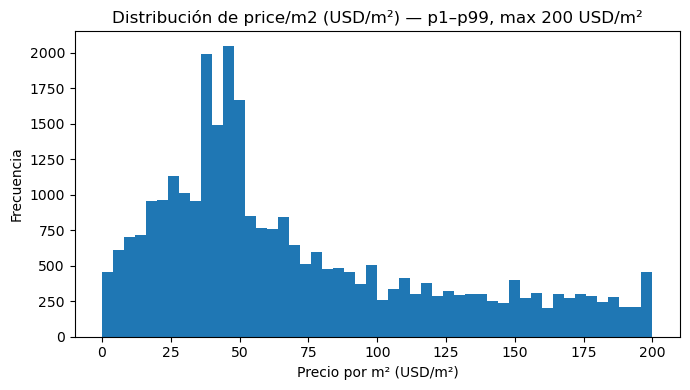

Filas totales en df_conv: 280121
Con price_m2 válido y <= 200 USD/m2: 29426 | Tras p1–p99: 29426
count    29426.000000
mean        71.694245
std         51.507763
min          0.100000
1%           2.700149
10%         18.125000
25%         35.416667
50%         52.011561
75%        101.814667
90%        158.095238
99%        199.333333
max        200.000000
Name: price_m2, dtype: float64
Modas de 100 muestras en distribución price/m2: 0    50.0
Name: price_m2, dtype: float64


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Serie limpia para graficar
s = (df_conv["price_m2"]
     .replace([np.inf, -np.inf], np.nan)
     .dropna())

# Filtrar valores mayores a 200 USD/m2
s = s[s <= 200]

# Recorte p1–p99
p1, p99 = s.quantile([0, 1])
s_clip = s.clip(lower=p1, upper=p99)

plt.figure(figsize=(7,4))
plt.hist(s_clip, bins=50)
plt.xlabel("Precio por m² (USD/m²)")
plt.ylabel("Frecuencia")
plt.title("Distribución de price/m2 (USD/m²) — p1–p99, max 200 USD/m²")
plt.tight_layout()
plt.show()

print(f"Filas totales en df_conv: {len(df_conv)}")
print(f"Con price_m2 válido y <= 200 USD/m2: {s.size} | Tras p1–p99: {s_clip.size}")
print(s.describe(percentiles=[.01,.1,.25,.5,.75,.9,.99]))

# calculo de modas de 100ts en distribución price / m2
modes = s_clip.mode()
print(f"Modas de 100 muestras en distribución price/m2: {modes}")

In [7]:
# calculo la media de price_m2

mean_price_m2 = df_conv["price_m2"].mean()

print(f"Media de price_m2: {mean_price_m2:.2f} USD/m²")

Media de price_m2: 1907.24 USD/m²


In [8]:
# Guardar el DataFrame convertido antes del procesamiento FastAI
df_conv.to_parquet("./train_2_Prework.parquet")

### 3. prework with fastai

In [9]:
# Importar las librerías necesarias
from fastai.tabular.all import *
import numpy as np
import pandas as pd

# La librería fastai tiene varias funcionalidad para preprocesar datasets. 
procs = [Categorify, FillMissing, Normalize]

# ===== 1) Preparar df y target =====
df = df_conv.copy()

# target precio/m2 con guardas
df["price_m2"] = df["price"] / df["surface_total"].replace(0, np.nan)
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")

# Limpiar outliers de price_m2
q1 = df["price_m2"].quantile(0.01)  # Usando percentil 1
q99 = df["price_m2"].quantile(0.99)  # Usando percentil 99
df = df[(df["price_m2"] >= q1) & (df["price_m2"] <= q99)].copy()

print(f"Registros después de filtrar outliers: {len(df)}")

# Eliminar variables correlativas con price_m2 y variables no informativas
variables_a_eliminar = ['price', 'surface_total', 'id', 'lat', 'lon']
df = df.drop(columns=variables_a_eliminar)

# ===== 2) Definir columnas =====
cat = [c for c in df.select_dtypes(include=["object","category"]).columns if c != "price_m2"]
cont = [c for c in df.select_dtypes(include=["number"]).columns if c != "price_m2"]

# ===== 3) Limpiar columnas problemáticas =====
all_nan_cols = [c for c in df.columns if df[c].isna().all() and c != "price_m2"]
constant_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1 and c != "price_m2"]
hi_null_cols = [c for c in df.columns if df[c].isna().mean() > 0.95 and c != "price_m2"]
to_drop = sorted(set(all_nan_cols) | set(constant_cols) | set(hi_null_cols))

print("\nDropping columns with problems:", to_drop)
df = df.drop(columns=to_drop)

# ===== 4) Redefinir columnas después de la limpieza =====
cont = [c for c in df.select_dtypes(include=["number"]).columns if c != "price_m2"]
cat = [c for c in df.columns if c not in cont + ["price_m2"]]

print("\nColumnas numéricas finales:", cont)
print("\nColumnas categóricas finales:", cat)
print("\nVerificar que price_m2 está en el DataFrame:", "price_m2" in df.columns)

# Split para entrenamiento/validación (80% train, 20% validation)
splits = RandomSplitter(valid_pct=0.2, seed=42)(range_of(df))  # valid_pct=0.2 significa 80% para train

Registros después de filtrar outliers: 274544

Dropping columns with problems: ['ad_type', 'currency', 'l5', 'l6', 'operation_type', 'price_period']

Columnas numéricas finales: ['rooms', 'bedrooms', 'bathrooms', 'surface_covered', 'covered_ratio', 'year_created', 'month_created', 'age_of_ad']

Columnas categóricas finales: ['start_date', 'end_date', 'created_on', 'pais', 'provincia', 'ciudad', 'barrio', 'title', 'description', 'property_type']

Verificar que price_m2 está en el DataFrame: True


### 4. Exportación

In [10]:
# Crear TabularPandas
to = TabularPandas(df, procs, cat, cont, y_names='price_m2', splits=splits)

# === BLOQUE SEGURO: usar salidas de TabularPandas para evitar NaN ===
try:
    X_train, y_train = to.train.xs.copy(), to.train.y.values.ravel()
    X_valid, y_valid = to.valid.xs.copy(), to.valid.y.values.ravel()
except NameError as e:
    raise RuntimeError("No existe el objeto 'to'. Asegúrate de haber creado TabularPandas antes.") from e

# Chequeos duros de NaN (deben dar 0)
print("NaN en X_train:", int(X_train.isna().sum().sum()))
print("NaN en X_valid:", int(X_valid.isna().sum().sum()))

# Guardar el objeto TabularPandas procesado
save_pickle('./df_train-tabular-object.pkl', to)

c:\Users\60083400\AppData\Local\anaconda3\Lib\site-packages\fastai\tabular\core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to[n].fillna(self.na_dict[n], inplace=True)
c:\Users\60083400\AppData\Local\anaconda3\Lib\site-packages\fastai\tabular\core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

NaN en X_train: 0
NaN en X_valid: 0
